In [1]:
# ==============================================================================
# CELL 1: IMPORTS & GLOBAL CONFIGURATION
# ==============================================================================

import jax
import jax.numpy as jnp
from jax import random, vmap

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# ------------------------------------------------------------------------------
# Numerical configuration
# ------------------------------------------------------------------------------
# Enable 64-bit floating-point precision in JAX.
#
# Higher numerical precision can be useful in dynamic programming calculations
# and helps reduce the impact of numerical rounding errors during backward
# induction and interpolation steps.
jax.config.update("jax_enable_x64", True)


# ------------------------------------------------------------------------------
# Plotting configuration
# ------------------------------------------------------------------------------
# Configure a consistent visual style for figures generated throughout the
# Proof-of-Concept.
sns.set_theme(style="whitegrid", palette="muted")


# ------------------------------------------------------------------------------
# Global model parameters
#
# These values define the stylized Proof-of-Concept environment used in this
# notebook. They should not be interpreted as calibrated estimates for any
# specific location, crop, or farming system.
# ------------------------------------------------------------------------------

params = {

    # Length of the simulated decision horizon (days)
    'days_in_season': 120,

    # Number of stochastic weather trajectories used in simulation exercises
    'n_paths': 5000,

    # --------------------------------------------------------------------------
    # Physical / agronomic parameters
    # --------------------------------------------------------------------------

    # Stylized soil-moisture persistence parameter.
    # In a production implementation, this parameter could depend on local soil
    # characteristics.
    'rho': 0.85,

    # Maximum soil moisture storage capacity used by the simplified soil module.
    # Moisture above this threshold is treated as excess water.
    'field_capacity': 100.0,

    # --------------------------------------------------------------------------
    # Economic / decision parameters
    # --------------------------------------------------------------------------

    # Discount factor used in Bellman recursion.
    'discount_factor': 0.99,

    # Constant Relative Risk Aversion (CRRA) coefficient used in illustrative
    # simulations of risk-sensitive decision-making.
    'risk_aversion': 2.0
}


# ------------------------------------------------------------------------------
# Discretized state-space grid
#
# The Bellman engine evaluates the value function on a finite moisture grid
# instead of a continuous state space. Future moisture states may fall between
# grid nodes and are handled through interpolation in later calculations.
# ------------------------------------------------------------------------------

M_BINS = 100

moisture_grid = jnp.linspace(
    0,
    params['field_capacity'],
    M_BINS
)

days_grid = jnp.arange(params['days_in_season'])


print(f"JAX Backend: {jax.devices()[0]}")
print(
    f"State Space Dimensions: "
    f"Time = {len(days_grid)} days, "
    f"Moisture = {M_BINS} discrete nodes"
)
print(f"Monte Carlo Paths: {params['n_paths']}")

JAX Backend: cpu:0
State Space Dimensions: Time = 120 days, Moisture = 100 discrete nodes
Monte Carlo Paths: 5000


In [ ]:
# ==============================================================================
# CELL 2/A: THE PREDICTIVE ENGINE (SYNTHETIC WEATHER SIMULATOR)
# ==============================================================================
# This cell defines a stylized stochastic weather generator.
# As stated in the documentation, this Proof of Concept (PoC) does not yet
# ingest live Deep Learning (DL) ensemble API feeds. Instead, it utilizes 
# this baseline to simulate the dimensional structure of a weather ensemble 
# (temperature, precipitation, sunshine, wind speed) and to demonstrate 
# the mechanics of dynamic information arrival (the collapse of uncertainty).

# Ensure global dimensions are set
N_PATHS = 1000
DAYS = 120

def generate_stochastic_weather(key, n_paths, days):
    """
    Generates synthetic Monte Carlo sample paths for exogenous weather variables.
    This serves as a structural placeholder for the probabilistic distributions
    that could be replaced by meteorological ensemble forecasts in future versions of the framework.
    """
    keys = random.split(key, 4)
    
    # 1. Temperature (T): Stylized sinusoidal baseline with additive Gaussian noise.
    T_base = 30.0 + 2.0 * jnp.sin(jnp.linspace(0, 3.14, days))
    T_paths = T_base + random.normal(keys[0], (n_paths, days)) * 2.0
    
    # 2. Precipitation (R): Log-normal distribution to approximate the right-skewed,
    # sparse and right-skewed rainfall patterns.
    R_raw = random.normal(keys[1], (n_paths, days))
    R_paths = jnp.where(R_raw > 1.0, jnp.exp(R_raw) * 5.0, 0.0)
    
    # 3. Sunshine (S): Inverse structural relationship to precipitation, 
    # with additive noise to simulate cloud cover variance.
    S_base = 12.0 - (R_paths > 0) * 4.0
    S_paths = jnp.clip(S_base + random.normal(keys[2], (n_paths, days)) * 1.5, 0.0, 14.0)
    
    # 4. Wind speed (W): Normal distribution bounded at zero.
    W_paths = jnp.maximum(10.0 + random.normal(keys[3], (n_paths, days)) * 5.0, 0.0)
    
    return T_paths, R_paths, S_paths, W_paths

# ------------------------------------------------------------------------------
# SYNTHETIC GROUND TRUTH
# ------------------------------------------------------------------------------
# We generate a single deterministic path to represent the realized weather 
# history. This allows the PoC to simulate how previously uncertain
# observations become known through time.
gt_key = random.PRNGKey(999)
T_gt, R_gt, S_gt, W_gt = generate_stochastic_weather(gt_key, 1, DAYS)

# ------------------------------------------------------------------------------
# DYNAMIC UPDATER (SIMULATING INFORMATION ARRIVAL)
# ------------------------------------------------------------------------------

def get_updated_forecast(current_day, forecast_key):
    """
    Illustrative forecast-update mechanism. The procedure replaces the historical portion 
    of the forecast with realized observations while leaving future periods uncertain. 
    This is used to visualize how the available information set changes through time.
    
    In future versions of the framework, updated forecasts could be obtained
    from an external meteorological forecasting system. 
    
    In this PoC, we mechanically replicate this process by splicing the static 
    synthetic 'ground truth' array (representing the observed past) with a newly 
    generated Monte Carlo ensemble (representing the uncertain future).
    """
    # Generate the uncertain future ensemble
    T_sim, R_sim, S_sim, W_sim = generate_stochastic_weather(forecast_key, N_PATHS, DAYS)
    
    def merge_truth_and_forecast(sim_tensor, truth_tensor):
        if current_day == 0:
            return sim_tensor
        # The observed past collapses to a probability of 1 (single trajectory)
        past = jnp.tile(truth_tensor[0, :current_day], (N_PATHS, 1))
        # The future remains a probabilistic distribution
        future = sim_tensor[:, current_day:]
        return jnp.concatenate([past, future], axis=1)
        
    T_upd = merge_truth_and_forecast(T_sim, T_gt)
    R_upd = merge_truth_and_forecast(R_sim, R_gt)
    S_upd = merge_truth_and_forecast(S_sim, S_gt)
    W_upd = merge_truth_and_forecast(W_sim, W_gt)
    
    return T_upd, R_upd, S_upd, W_upd

# Initialize the baseline environment (Day 0 forecast) for the Bellman engine
rng_key = random.PRNGKey(42)
T_sim, R_sim, S_sim, W_sim = get_updated_forecast(0, rng_key)

print(f"Synthetic Weather Generator initialized. Tensor Shape: {T_sim.shape}")

Synthetic Weather Generator initialized. Tensor Shape: (1000, 120)


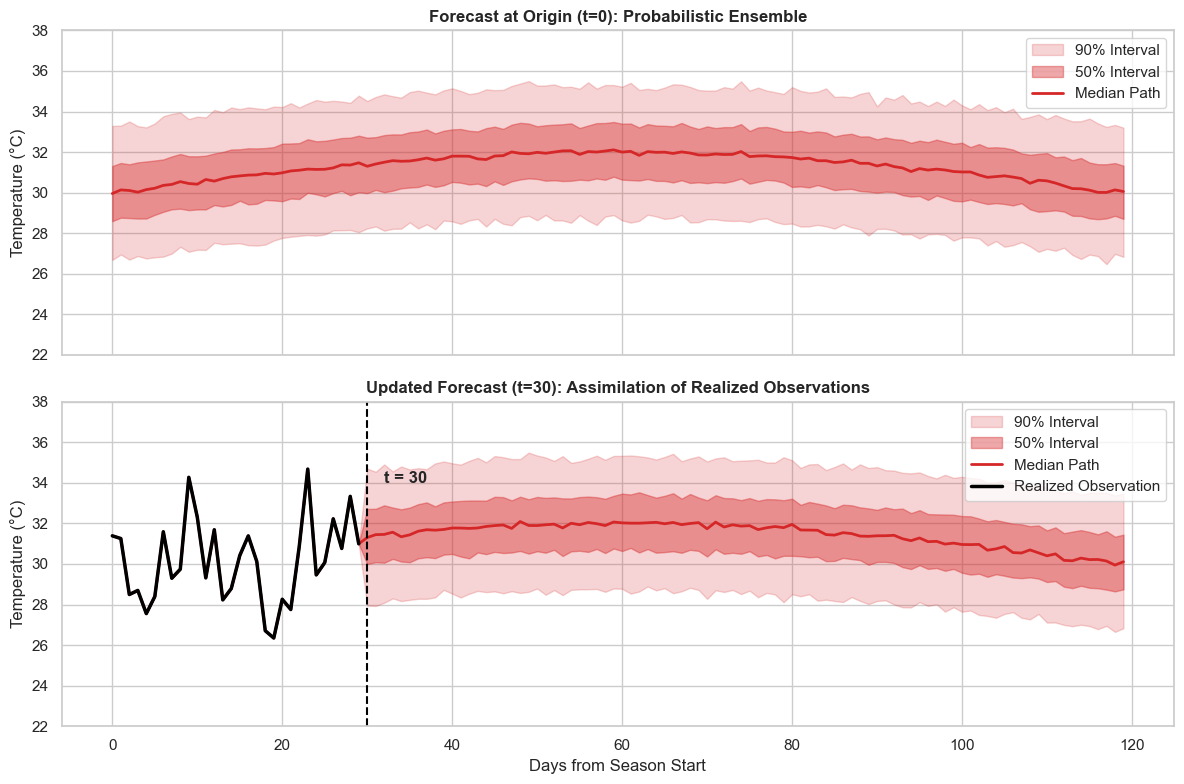

In [4]:
# ==============================================================================
# CELL 2/B: VISUALIZING THE ROLLING FORECAST (INFORMATION ARRIVAL)
# ==============================================================================
# This cell provides a visual representation of the informational martingale
# property discussed in Appendix B of the documentation. It plots the
# empirical probability intervals of the synthetic ensemble and demonstrates
# how realized observations replace probabilistic forecasts over time.

def plot_dynamic_forecast(ax, data_tensor, current_day, title):
    """
    Renders a fan chart of the state variable (e.g., Temperature) across the 
    decision horizon. Visualizes the reduction in state uncertainty as the 
    simulated observation day advances.
    """
    days = np.arange(data_tensor.shape[1])
    
    # Calculate empirical percentiles across the ensemble dimension (N_PATHS)
    # to establish probability intervals.
    p5 = np.percentile(data_tensor, 5, axis=0)
    p25 = np.percentile(data_tensor, 25, axis=0)
    median = np.percentile(data_tensor, 50, axis=0)
    p75 = np.percentile(data_tensor, 75, axis=0)
    p95 = np.percentile(data_tensor, 95, axis=0)
    
    # --- 1. Plot the probability intervals ---
    # Note: The current synthetic generator utilizes IID noise, yielding 
    # constant variance across the horizon. DL ensembles in production 
    # would exhibit lead-time dependent variance.
    ax.fill_between(days, p5, p95, color='tab:red', alpha=0.2, label='90% Interval')
    ax.fill_between(days, p25, p75, color='tab:red', alpha=0.4, label='50% Interval')
    
    # --- 2. Plot the expected path ---
    ax.plot(days, median, color='tab:red', linewidth=2, label='Median Path')
    
    # --- 3. Overlay realized observations ---
    # For t <= current_day, the state is treated as deterministic in this PoC.
    if current_day > 0:
        ax.plot(days[:current_day], data_tensor[0, :current_day], 
                color='black', linewidth=2.5, label='Realized Observation')
        
        # Demarcate the current simulation day (t)
        ax.axvline(x=current_day, color='black', linestyle='--', linewidth=1.5)
        ax.text(current_day + 2, 34, f't = {current_day}', fontweight='bold')

    # Formatting and aesthetics
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Temperature (°C)')
    ax.set_ylim(22, 38)
    ax.legend(loc='upper right')

# Generate the Day 0 forecast (Origin) and Day 30 forecast (Updated state)
key_30 = random.PRNGKey(101)
T_day0, _, _, _ = get_updated_forecast(0, rng_key)
T_day30, _, _, _ = get_updated_forecast(30, key_30)

# Render the subplots sequentially to illustrate information arrival
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

plot_dynamic_forecast(ax1, T_day0, 0, "Forecast at Origin (t=0): Probabilistic Ensemble")
plot_dynamic_forecast(ax2, T_day30, 30, "Updated Forecast (t=30): Assimilation of Realized Observations")

ax2.set_xlabel('Days from Season Start')
plt.tight_layout()
plt.show()

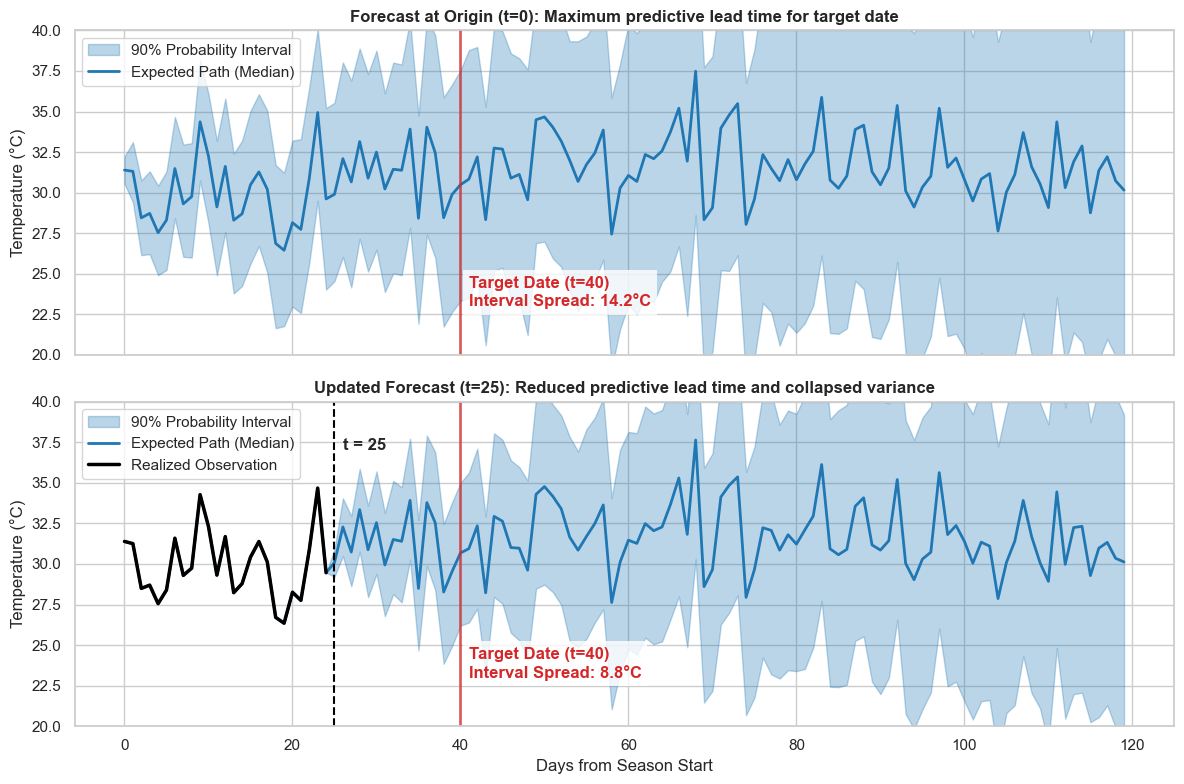

In [ ]:
# ==============================================================================
# CELL 2/C: VISUALIZING LEAD-TIME DEPENDENT VARIANCE (THE MARTINGALE PROPERTY)
# ==============================================================================

def get_realistic_dynamic_forecast(current_day, forecast_key):
    """
    Simulates lead-time dependent variance to reflect the informational 
    martingale property of meteorological forecasting. In operational models, 
    uncertainty is not constant; it scales with the temporal distance 
    (lead time) to the target date.
    """
    keys = random.split(forecast_key, 4)
    days_array = jnp.arange(DAYS)
    
    # Lead time: 0 for past/present, increases linearly into the future.
    lead_time = jnp.maximum(0, days_array - current_day)
    
    # Uncertainty (Standard Deviation) scales with the square root of lead time.
    # This approximates the accumulation of atmospheric variance. As the simulation 
    # advances toward a target date, the lead time decreases, reducing the spread.
    T_std = 0.5 + 0.6 * jnp.sqrt(lead_time)
    
    # Generate heteroskedastic noise (dynamically scaling standard deviation)
    T_noise = random.normal(keys[0], (N_PATHS, DAYS)) * T_std
    
    # Anchor the ensemble mean to the realized trajectory.
    # This enforces convergence toward the observed state as lead time approaches zero.
    T_paths = T_gt + T_noise
    
    # Observations prior to the current day are deterministic.
    past_mask = days_array < current_day
    T_paths = jnp.where(past_mask, T_gt, T_paths)
    
    return T_paths

def plot_shrinking_target_uncertainty():
    """
    Renders the evolution of forecast uncertainty for a fixed target date. 
    Comparing the state space at t=0 and t=25 illustrates the reduction in 
    forecast uncertainty associated with the arrival of additional information..
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    TARGET_DAY = 40  # The fixed future date evaluated (e.g., biological window start)
    
    # 1. Baseline Forecast (Origin: t=0)
    key_0 = random.PRNGKey(200)
    T_day0 = get_realistic_dynamic_forecast(0, key_0)
    
    # 2. Updated Forecast (Origin: t=25)
    key_25 = random.PRNGKey(201)
    T_day25 = get_realistic_dynamic_forecast(25, key_25)
    
    def format_ax(ax, data_tensor, current_day, title):
        days = np.arange(DAYS)
        p5 = np.percentile(data_tensor, 5, axis=0)
        p95 = np.percentile(data_tensor, 95, axis=0)
        median = np.percentile(data_tensor, 50, axis=0)
        
        ax.fill_between(days, p5, p95, color='tab:blue', alpha=0.3, label='90% Probability Interval')
        ax.plot(days, median, color='tab:blue', linewidth=2, label='Expected Path (Median)')
        
        if current_day > 0:
            ax.plot(days[:current_day], data_tensor[0, :current_day], 
                    color='black', linewidth=2.5, label='Realized Observation')
            ax.axvline(x=current_day, color='black', linestyle='--', linewidth=1.5)
            ax.text(current_day + 1, 37, f't = {current_day}', fontweight='bold')
        
        # --- Highlight the target date (informational gain) ---
        ax.axvline(x=TARGET_DAY, color='tab:red', linestyle='-', linewidth=2, alpha=0.7)
        interval_width = p95[TARGET_DAY] - p5[TARGET_DAY]
        ax.text(TARGET_DAY + 1, 23, f'Target Date (t={TARGET_DAY})\nInterval Spread: {interval_width:.1f}°C', 
                color='tab:red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_ylabel('Temperature (°C)')
        ax.set_ylim(20, 40)
        ax.legend(loc='upper left')

    format_ax(ax1, T_day0, 0, "Forecast at Origin (t=0): Maximum predictive lead time for target date")
    format_ax(ax2, T_day25, 25, "Updated Forecast (t=25): Reduced predictive lead time and collapsed variance")
    
    ax2.set_xlabel('Days from Season Start')
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_shrinking_target_uncertainty()

In [8]:
# ==============================================================================
# CELL 3: ENDOGENOUS SOIL MOISTURE DYNAMICS (FAO-56 PHYSICAL ENGINE)
# ==============================================================================

# --- Agronomic & Hydrological Parameters (PoC Baseline Specification) ---
# As noted in Appendix A, these parameters would be calibrated via spatial 
# GIS databases (e.g., SoilGrids) in an operational deployment.
FC = params['field_capacity']  # Field Capacity (mm)
PWP = 20.0                     # Permanent Wilting Point (mm)
K_c = 0.20                     # Basal crop coefficient for bare soil

@jax.jit
def soil_moisture_step(M_prev, weather_t):
    """
    Evaluates the structural water balance difference equation for a single time step:
    M_{t+1} = M_t + R_t - ET_a - D_t
    
    This implementation follows a simplified FAO-56 'bucket model' methodology 
    to maintain basic hydrological consistency within the state space.
    """
    T, R, S, W = weather_t
    
    # 1. Reference Evapotranspiration (ET_0)
    # A stylized approximation combining a radiation-driven term and an 
    # aerodynamic-driven term.
    rad_term = 0.15 * S * jnp.maximum(0.0, T - 10.0) 
    aero_term = 0.05 * W * jnp.maximum(0.0, T - 15.0)
    ET_0 = rad_term + aero_term
    
    # 2. Soil Water Stress Coefficient (K_s)
    # Introduces a state-dependent, non-linear decay in moisture depletion 
    # as the soil state approaches the Permanent Wilting Point.
    K_s = jnp.clip((M_prev - PWP) / (FC - PWP), 0.0, 1.0)
    
    # 3. Actual Evapotranspiration (ET_a)
    ET_a = K_c * K_s * ET_0
    
    # 4. Baseline Water Balance
    M_raw = M_prev + R - ET_a
    
    # 5. Deep Percolation & Runoff (D)
    # In this simplified representation, moisture exceeding Field Capacity
    # is removed from the state variable.
    D = jnp.maximum(0.0, M_raw - FC)
    
    # 6. Terminal State (Bounded between zero and Field Capacity)
    M_next = jnp.clip(M_raw - D, 0.0, FC)
    
    return M_next, M_next

@jax.jit
def simulate_moisture(M0, T_seq, R_seq, S_seq, W_seq):
    """
    Recursively applies the discrete-time soil moisture step across the horizon.
    Vectorized over the ensemble paths (N_PATHS).
    """
    # Transpose weather tensors to shape: (days, paths) for the scan loop
    weather_seq = (T_seq.T, R_seq.T, S_seq.T, W_seq.T)
    
    # jax.lax.scan compiles the recurrence relation via XLA, avoiding 
    # Python control flow overhead during iterative execution.
    _, M_history = jax.lax.scan(soil_moisture_step, M0, weather_seq)
    
    return M_history.T # Transpose back to (paths, days)

# Infer the ensemble size from the generated weather tensor
n_paths = T_sim.shape[0]

# Initialize the starting moisture state for all ensemble members.
# The baseline specification assumes 50% of Field Capacity at t=0.
M0 = jnp.ones(n_paths) * (FC * 0.50)

# Execute the vectorized moisture simulation
M_sim = simulate_moisture(M0, T_sim, R_sim, S_sim, W_sim)

print(f"Endogenous Soil Moisture Tensor Shape: {M_sim.shape}")
print(f"Sample Moisture levels on Day 10 (first 5 paths, in mm): \n{M_sim[:5, 10]}")

Endogenous Soil Moisture Tensor Shape: (1000, 120)
Sample Moisture levels on Day 10 (first 5 paths, in mm): 
[41.41560458 64.74270056 28.50430137 40.2660375  50.66639259]


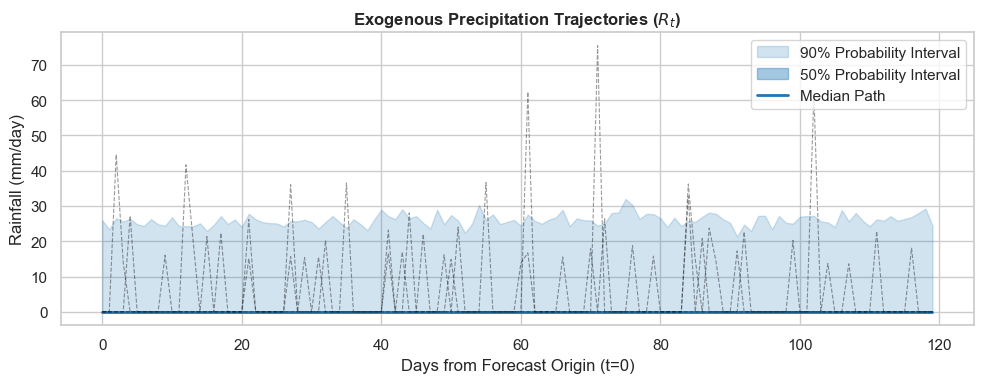

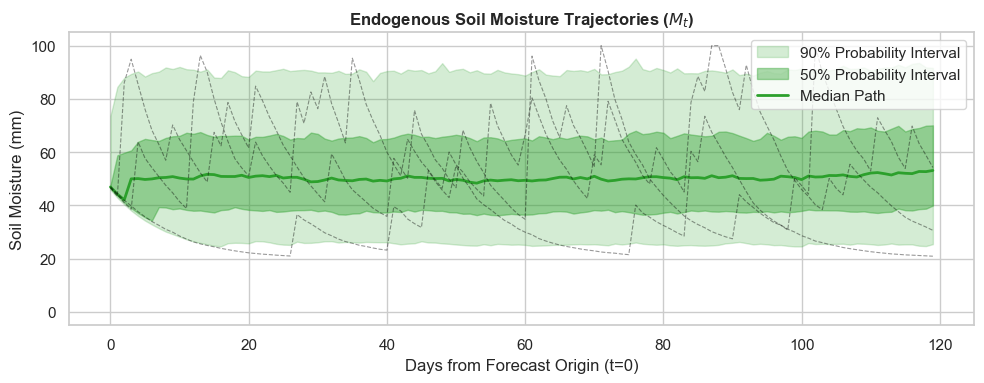

In [9]:
# ==============================================================================
# CELL 4: VISUALIZING THE STATE SPACE (EXOGENOUS SHOCKS VS. ENDOGENOUS STATE)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

def plot_fan_chart(data_tensor, title, ylabel, color, ylim=None):
    """
    Generates a fan chart to visualize the dispersion of the simulated trajectories.
    
    Computes empirical probability intervals across the simulated ensemble (N_PATHS).
    Individual stochastic realizations are overlaid to illustrate the underlying 
    variance of single trajectory paths compared to the smoothed ensemble median.
    """
    days = np.arange(data_tensor.shape[1])
    
    # Calculate empirical percentiles across the ensemble dimension (axis=0)
    p5 = np.percentile(data_tensor, 5, axis=0)
    p25 = np.percentile(data_tensor, 25, axis=0)
    median = np.percentile(data_tensor, 50, axis=0)
    p75 = np.percentile(data_tensor, 75, axis=0)
    p95 = np.percentile(data_tensor, 95, axis=0)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot empirical probability intervals
    ax.fill_between(days, p5, p95, color=color, alpha=0.2, label='90% Probability Interval')
    ax.fill_between(days, p25, p75, color=color, alpha=0.4, label='50% Probability Interval')
    
    # Plot the ensemble median
    ax.plot(days, median, color=color, linewidth=2, label='Median Path')
    
    # Overlay a subset of individual paths to illustrate trajectory variance
    for i in range(3):
        ax.plot(days, data_tensor[i, :], color='black', alpha=0.4, linewidth=0.8, linestyle='--')
        
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Days from Forecast Origin (t=0)')
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(ylim)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# --- PLOT 1: THE EXOGENOUS SHOCK (PRECIPITATION) ---
# Visualizes the right-skewed, sparse distribution of the simulated rainfall.
# In a production environment, this data would be sourced from the DL ensemble.
plot_fan_chart(R_sim, 
               title='Exogenous Precipitation Trajectories ($R_t$)', 
               ylabel='Rainfall (mm/day)', 
               color='tab:blue')

# --- PLOT 2: THE ENDOGENOUS STATE VARIABLE (SOIL MOISTURE) ---
# Output of the discrete-time FAO-56 structural water balance equation.
# Demonstrates the autoregressive, bounded nature of the soil moisture state, 
# which acts as a physical buffer for the exogenous precipitation shocks.
plot_fan_chart(M_sim, 
               title='Endogenous Soil Moisture Trajectories ($M_t$)', 
               ylabel='Soil Moisture (mm)', 
               color='tab:green', 
               ylim=(-5, params['field_capacity'] + 5)) # Dynamically bounded by FC

In [ ]:
# ==============================================================================
# CELL 5: THE DECISION ENGINE (BACKWARD INDUCTION ON STATE SPACE)
# ==============================================================================
# This cell executes the core Stochastic Dynamic Programming (SDP) engine.
# As explicitly stated in the Proof of Concept documentation, this baseline 
# iteration employs a Certainty Equivalence heuristic: it collapses the 
# stochastic weather ensembles into deterministic means prior to evaluation.

# Ensure agronomic parameters are consistent with the physical engine (Cell 3)
FC = params['field_capacity']
PWP = 20.0
K_c_bare = 0.20  # Basal crop coefficient for bare soil (pre-planting phase)
BETA = params['discount_factor']  # Discount factor for time preference

# Discretize the Moisture State Space
M_BINS = 100
M_GRID = jnp.linspace(0.0, FC, M_BINS)

# Infer the decision horizon from the temporal dimension of the weather tensor
DAYS = T_sim.shape[1]

# Apply Certainty Equivalence: Collapse Monte Carlo paths into deterministic expectations
E_rain = jnp.array(np.mean(R_sim, axis=0))
E_T = jnp.array(np.mean(T_sim, axis=0))
E_S = jnp.array(np.mean(S_sim, axis=0))
E_W = jnp.array(np.mean(W_sim, axis=0))

# Biological requirements for the crop (FAO-56 tabulated parameters)
GDD_REQ = 1200.0  # Total required thermal time (Growing Degree Days)
T_BASE = 10.0     # Base temperature for phenological development
Y_MAX = 100.0     # Maximum theoretical yield potential
K_Y = 1.2         # FAO Yield response factor to water stress

@jax.jit
def expected_yield(t, m, forward_rain_sum, forward_T_mean, days_remaining):
    """
    Evaluates the stylized terminal yield function used in the Proof-of-Concept implementation.
    
    The function combines thermal-time, water-stress and establishment penalties 
    described in the accompanying documentation.
    """
    # 1. Thermal Time Constraint (P_thermal)
    expected_daily_gdd = jnp.maximum(0.0, forward_T_mean - T_BASE)
    total_gdd_accumulated = expected_daily_gdd * days_remaining
    thermal_penalty = jnp.clip(total_gdd_accumulated / GDD_REQ, 0.0, 1.0)
    
    # 2. Water Stress Penalty (P_water)
    water_available = m + forward_rain_sum
    water_need = 3.5 * days_remaining
    et_ratio = jnp.clip(water_available / jnp.maximum(water_need, 1.0), 0.0, 1.0)
    water_stress_penalty = 1.0 - K_Y * (1.0 - et_ratio)
    water_stress_penalty = jnp.clip(water_stress_penalty, 0.0, 1.0)
    
    # 3. Initial Establishment Penalty (P_germ)
    # Embeds the strict dependency on the initial soil moisture state.
    # Moisture levels below the threshold receive increasingly severe
    # establishment penalties in this stylized specification.
    establishment_threshold = 0.30 * FC
    germination_penalty = jnp.clip(m / establishment_threshold, 0.0, 1.0)
    
    # 4. Terminal Yield Function (Multiplicative constraints)
    y = Y_MAX * thermal_penalty * water_stress_penalty * germination_penalty
    
    # Stylized seasonal cutoff used in the PoC.
    y = jnp.where(days_remaining < 30, 0.0, y)
    
    return y

@jax.jit
def dp_step(t, V_next, e_R, e_T, e_S, e_W, forward_rain_sum, forward_T_mean, days_remaining):
    """
    Evaluates the Bellman equation for a single time step t:
    V_t(M_t) = max { Pi(M_t, t), Beta * E[V_{t+1}(M_{t+1})] }
    Vectorized across the entire discretized moisture state space (M_GRID).
    """
    # --- OPTION 1: EXECUTE IRREVERSIBLE ACTION (PLANT) ---
    yield_current = expected_yield(t, M_GRID, forward_rain_sum, forward_T_mean, days_remaining)
    
    # --- OPTION 2: DELAY ACTION (WAIT) ---
    # Project the endogenous soil moisture state forward (M_{t+1})
    rad_term = 0.15 * e_S * jnp.maximum(0.0, e_T - 10.0)
    aero_term = 0.05 * e_W * jnp.maximum(0.0, e_T - 15.0)
    ET_0 = rad_term + aero_term
    
    K_s = jnp.clip((M_GRID - PWP) / (FC - PWP), 0.0, 1.0)
    ET_a = K_c_bare * K_s * ET_0
    
    M_raw = M_GRID + e_R - ET_a
    D = jnp.maximum(0.0, M_raw - FC)
    m_next_mean = jnp.clip(M_raw - D, 0.0, FC)
    
    # Interpolate the continuation value from the t+1 Value Function
    continuation_value = BETA * jnp.interp(m_next_mean, M_GRID, V_next)
    
    # --- BELLMAN VALUE FUNCTION UPDATE ---
    V_current = jnp.maximum(yield_current, continuation_value)
    policy = (yield_current > continuation_value).astype(jnp.int32)
    
    return V_current, policy

@jax.jit
def run_backward_induction(e_R_seq, e_T_seq, e_S_seq, e_W_seq, f_rain_seq, f_T_seq):
    """
    Executes the backward induction algorithm over the decision horizon.
    Utilizes JAX/XLA graph fusion (jax.lax.scan) to vectorize temporal 
    evaluation, minimizing Python control flow overhead.
    """
    days_arr = jnp.arange(DAYS, dtype=jnp.float64)
    days_rem_arr = jnp.array([float(DAYS - t) for t in range(DAYS)])
    
    # Structure the exogenous time-series sequences
    step_data = (days_arr, e_R_seq, e_T_seq, e_S_seq, e_W_seq, f_rain_seq, f_T_seq, days_rem_arr)
    
    # Reverse sequences along the time axis (from T_max down to t=0)
    step_data_rev = jax.tree_util.tree_map(lambda x: jnp.flip(x, axis=0), step_data)
    
    def scan_fn(V_next, current_step_data):
        t, e_R, e_T, e_S, e_W, f_R, f_T, d_rem = current_step_data
        V_current, policy = dp_step(t, V_next, e_R, e_T, e_S, e_W, f_R, f_T, d_rem)
        return V_current, (V_current, policy)

    # Initialize terminal condition V_{T_max} = 0
    V_init = jnp.zeros(M_BINS)
    
    # Execute the XLA-compiled scan loop
    V_final, (V_history_rev, pol_history_rev) = jax.lax.scan(scan_fn, V_init, step_data_rev)
    
    # Revert the output matrices to chronological order
    V_history = jnp.flip(V_history_rev, axis=0)
    pol_history = jnp.flip(pol_history_rev, axis=0)
    
    return V_history, pol_history

# Pre-calculate sequence expectations for the Certainty Equivalence heuristic
forward_rain_sums = jnp.array([jnp.sum(E_rain[t:]) for t in range(DAYS)])
forward_T_means = jnp.array([jnp.mean(E_T[t:]) if t < DAYS-1 else 0.0 for t in range(DAYS)])

print(f"Executing XLA-compiled backward induction over {DAYS} periods.")

# Evaluate the Value Function
value_matrix, policy_matrix = run_backward_induction(
    E_rain, E_T, E_S, E_W, forward_rain_sums, forward_T_means
)

print(f"Backward induction completed. Policy surface dimensions: {policy_matrix.shape}")

Executing XLA-compiled backward induction over 120 periods.
Backward induction completed. Policy surface dimensions: (120, 100)


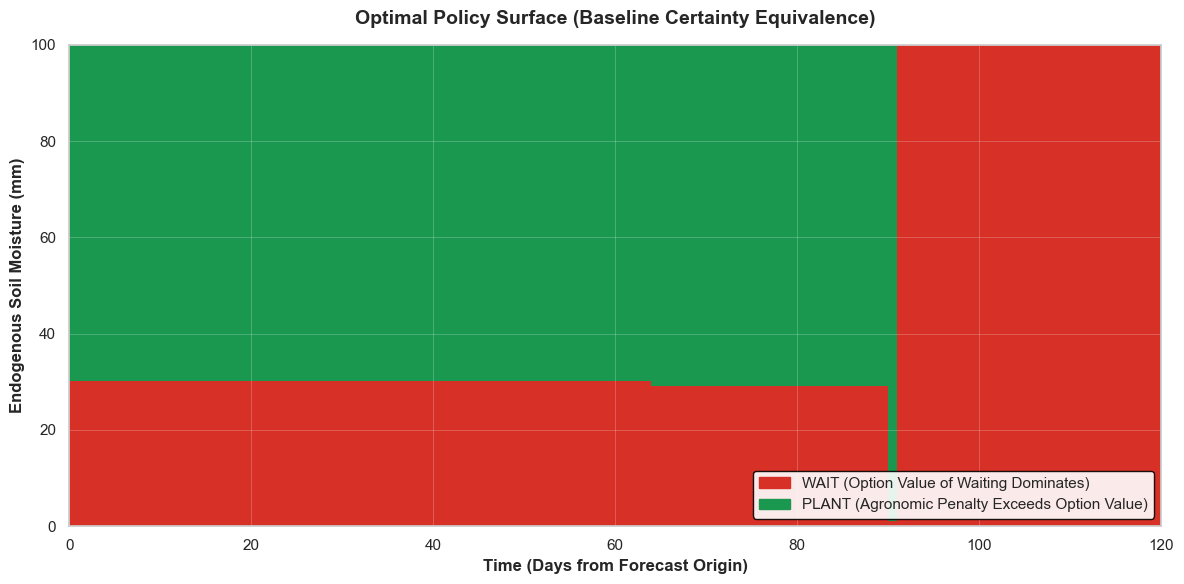

In [12]:
# ==============================================================================
# CELL 6: VISUALIZATION OF THE POLICY SURFACE (HEATMAP)
# ==============================================================================

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_policy_heatmap(policy_mat, days, max_moisture):
    """
    Renders the discrete policy matrix evaluated by the backward induction engine.
    Maps the binary action space (0: Wait, 1: Plant) onto the physical state space 
    (Time and Soil Moisture).
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define binary color map: Red for WAIT (0), Green for PLANT (1)
    cmap = ListedColormap(['#d73027', '#1a9850'])
    
    # Transpose the policy matrix to align Time (days) on the X-axis 
    # and Soil Moisture on the Y-axis. The 'extent' maps array indices 
    # to the physical state-space dimensions.
    im = ax.imshow(policy_mat.T, aspect='auto', origin='lower', 
                   cmap=cmap, extent=[0, days, 0, max_moisture])
    
    # --- Formatting and aesthetics ---
    ax.set_title("Optimal Policy Surface (Baseline Certainty Equivalence)", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Time (Days from Forecast Origin)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Endogenous Soil Moisture (mm)", fontsize=12, fontweight='bold')
    
    # Grid overlay to denote state space discretization
    ax.grid(color='white', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Legend mapping binary actions to their interpretation within the PoC decision framework
    wait_patch = mpatches.Patch(color='#d73027', label='WAIT (Option Value of Waiting Dominates)')
    plant_patch = mpatches.Patch(color='#1a9850', label='PLANT (Agronomic Penalty Exceeds Option Value)')
    ax.legend(handles=[wait_patch, plant_patch], loc='lower right', 
              framealpha=0.9, edgecolor='black')
    
    plt.tight_layout()
    plt.show()

# Extract dimensions for the plot boundaries
TOTAL_DAYS = policy_matrix.shape[0]
MAX_MOISTURE_MM = params['field_capacity']

# Render the policy heatmap
plot_policy_heatmap(policy_matrix, TOTAL_DAYS, MAX_MOISTURE_MM)

Evaluating CRRA Policy Surface (gamma = 0.0)...
Evaluating CRRA Policy Surface (gamma = 2.0)...


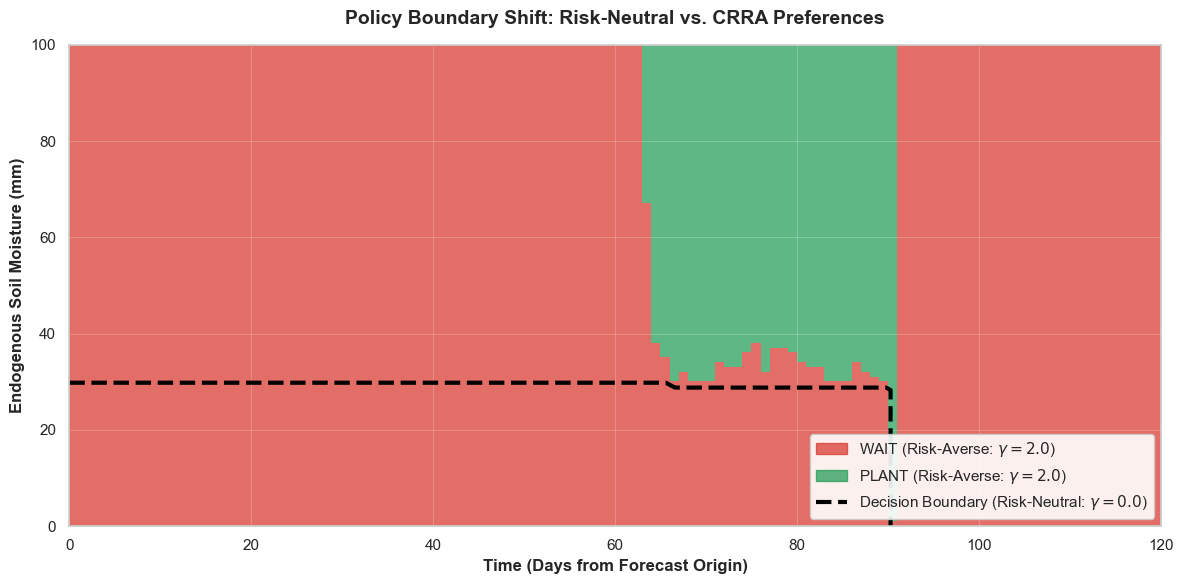

In [ ]:
# ==============================================================================
# CELL 7: STOCHASTIC MDP DEMONSTRATION (CRRA UTILITY PREFERENCES)
# ==============================================================================
# This cell operationalizes the Constant Relative Risk Aversion (CRRA) utility 
# demonstration as outlined in the documentation. It relaxes the certainty 
# equivalence heuristic for the terminal action, evaluating expected utility 
# across the full stochastic ensemble to capture extreme downside tail-risks.

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Retrieve structural parameters from the baseline environment
FC = params['field_capacity']
PWP = 20.0
K_c_bare = 0.20
BETA = params['discount_factor']
M_BINS = 100
M_GRID = jnp.linspace(0.0, FC, M_BINS)
DAYS = T_sim.shape[1]
N_PATHS = R_sim.shape[0]

# Stylized biological parameters used in the PoC
GDD_REQ = 1200.0
T_BASE = 10.0
Y_MAX = 100.0
K_Y = 1.2
SUBSISTENCE_FLOOR = 1.0 # Parameter 'c' to bound utility at zero yield

# 1. PRE-COMPUTE ENSEMBLE FORWARD TRAJECTORIES
# To evaluate E[U(Y)], the expectation operator is applied over the full 
# distribution (N_PATHS) rather than the deterministic mean.
forward_R_ensemble = jnp.array([jnp.sum(R_sim[:, t:], axis=1) for t in range(DAYS)])
forward_T_ensemble = jnp.array([jnp.mean(T_sim[:, t:], axis=1) if t < DAYS-1 else jnp.zeros(N_PATHS) for t in range(DAYS)])

@jax.jit
def crra_utility(y, gamma):
    """
    Constant Relative Risk Aversion (CRRA) Utility Function.
    Translates physical yield realizations into expected economic utility.
    """
    # Incorporates a subsistence floor to prevent undefined log or division by zero
    safe_y = y + SUBSISTENCE_FLOOR
    
    # jax.lax.cond gracefully handles the limit case where gamma == 1.0 (log utility)
    return jax.lax.cond(
        gamma == 1.0,
        lambda y_val: jnp.log(y_val),
        lambda y_val: (y_val**(1.0 - gamma)) / (1.0 - gamma),
        safe_y
    )

@jax.jit
def ensemble_expected_utility(t, m, f_R_paths, f_T_paths, days_rem, gamma):
    """
    Evaluates E[U(Y_a)] across the complete Monte Carlo ensemble for a given state.
    """
    # Vectorized yield evaluation across all sample paths simultaneously
    expected_daily_gdd = jnp.maximum(0.0, f_T_paths - T_BASE)
    total_gdd = expected_daily_gdd * days_rem
    thermal_pen = jnp.clip(total_gdd / GDD_REQ, 0.0, 1.0)
    
    water_available = m + f_R_paths
    water_need = 3.5 * days_rem
    et_ratio = jnp.clip(water_available / jnp.maximum(water_need, 1.0), 0.0, 1.0)
    water_pen = jnp.clip(1.0 - K_Y * (1.0 - et_ratio), 0.0, 1.0)
    
    germination_pen = jnp.clip(m / (0.30 * FC), 0.0, 1.0)
    
    y_paths = Y_MAX * thermal_pen * water_pen * germination_pen
    y_paths = jnp.where(days_rem < 30, 0.0, y_paths)
    
    # Calculate utility for each stochastic realization, then compute the expectation
    u_paths = crra_utility(y_paths, gamma)
    return jnp.mean(u_paths)

@jax.jit
def dp_step_stochastic(t, V_next, e_R, e_T, e_S, e_W, f_R_paths, f_T_paths, days_rem, gamma):
    """
    Evaluates the Bellman equation under CRRA preferences.
    Note: For this localized PoC, the one-period state transition (M_{t+1}) 
    utilizes the certainty-equivalent drift, while the terminal payout (Plant) 
    integrates over the full stochastic variance.
    """
    # 1. Expected Utility of Action: Plant
    # jax.vmap evaluates the ensemble utility across the discretized moisture grid
    vmap_plant = jax.vmap(ensemble_expected_utility, in_axes=(None, 0, None, None, None, None))
    U_plant = vmap_plant(t, M_GRID, f_R_paths, f_T_paths, days_rem, gamma)
    
    # 2. Expected Continuation Value: Wait
    rad_term = 0.15 * e_S * jnp.maximum(0.0, e_T - 10.0)
    aero_term = 0.05 * e_W * jnp.maximum(0.0, e_T - 15.0)
    ET_0 = rad_term + aero_term
    
    K_s = jnp.clip((M_GRID - PWP) / (FC - PWP), 0.0, 1.0)
    ET_a = K_c_bare * K_s * ET_0
    
    M_raw = M_GRID + e_R - ET_a
    D = jnp.maximum(0.0, M_raw - FC)
    m_next_mean = jnp.clip(M_raw - D, 0.0, FC)
    
    U_wait = BETA * jnp.interp(m_next_mean, M_GRID, V_next)
    
    # 3. Bellman Maximization
    V_current = jnp.maximum(U_plant, U_wait)
    policy = (U_plant > U_wait).astype(jnp.int32)
    
    return V_current, policy

def solve_crra_policy(gamma_value):
    """
    Iterates backward through time to solve the stylized dynamic programming
    problem for a specified CRRA coefficient (gamma).
    """
    # Terminal condition
    V_t = crra_utility(jnp.zeros(M_BINS), gamma_value) 
    policy_matrix = np.zeros((DAYS, M_BINS))
    
    # Pre-compute one-period transition drift for the continuation value
    e_R = np.mean(R_sim, axis=0)
    e_T = np.mean(T_sim, axis=0)
    e_S = np.mean(S_sim, axis=0)
    e_W = np.mean(W_sim, axis=0)
    
    print(f"Evaluating CRRA Policy Surface (gamma = {gamma_value})...")
    for t in reversed(range(DAYS)):
        days_rem = float(DAYS - t)
        V_t, pol_t = dp_step_stochastic(
            float(t), V_t, 
            e_R[t], e_T[t], e_S[t], e_W[t],
            forward_R_ensemble[t, :], forward_T_ensemble[t, :], 
            days_rem, gamma_value
        )
        policy_matrix[t, :] = pol_t
    return policy_matrix

# Execute comparative scenarios: Risk-Neutral vs. Risk-Averse
policy_neutral = solve_crra_policy(gamma_value=0.0)
policy_averse = solve_crra_policy(gamma_value=2.0)

# --- VISUALIZATION: CRRA POLICY COMPARISON ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Risk-Averse policy surface (gamma = 2.0) as the baseline heatmap
cmap = plt.cm.colors.ListedColormap(['#d73027', '#1a9850'])
ax.imshow(policy_averse.T, aspect='auto', origin='lower', 
          cmap=cmap, extent=[0, DAYS, 0, FC], alpha=0.7)

# Overlay the Risk-Neutral policy boundary (gamma = 0.0)
ax.contour(policy_neutral.T, levels=[0.5], colors='black', 
           linewidths=3, linestyles='dashed', extent=[0, DAYS, 0, FC])

# Formatting
ax.set_title("Policy Boundary Shift: Risk-Neutral vs. CRRA Preferences", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Time (Days from Forecast Origin)", fontsize=12, fontweight='bold')
ax.set_ylabel("Endogenous Soil Moisture (mm)", fontsize=12, fontweight='bold')

# Custom legends integrating economic interpretation
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
wait_patch = mpatches.Patch(color='#d73027', alpha=0.7, label='WAIT (Risk-Averse: $\gamma=2.0$)')
plant_patch = mpatches.Patch(color='#1a9850', alpha=0.7, label='PLANT (Risk-Averse: $\gamma=2.0$)')
neutral_line = mlines.Line2D([], [], color='black', linewidth=3, linestyle='dashed', 
                             label='Decision Boundary (Risk-Neutral: $\gamma=0.0$)')

ax.legend(handles=[wait_patch, plant_patch, neutral_line], loc='lower right', framealpha=0.9)
ax.grid(color='white', linestyle='-', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()